In [1]:
# %%
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from nltk.tokenize import TweetTokenizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

print(dataset)
print(dataset["train"][:5])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
{'text': ['"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', '"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"', 'Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.', "Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays", '@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"'], 'label': [2, 1, 1, 1, 2]}


In [3]:
train_df = pd.DataFrame(dataset["train"])
validation_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

                                                text  label
0  "QT @user In the original draft of the 7th boo...      2
1  "Ben Smith / Smith (concussion) remains out of...      1
2  Sorry bout the stream last night I crashed out...      1
3  Chase Headley's RBI double in the 8th inning o...      1
4  @user Alciato: Bee will invest 150 million in ...      2


In [4]:
class_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

In [6]:
# %%
class_counts = train_df["label"].value_counts().sort_index()

for label, count in class_counts.items():
    print(f"{class_names[label]}: {count}")

Negative: 7093
Neutral: 20673
Positive: 17849


In [7]:
class_frequency = {
    class_names[label]: count
    for label, count in class_counts.items()
}

print(class_frequency)

{'Negative': 7093, 'Neutral': 20673, 'Positive': 17849}


In [8]:

tokenizer = TweetTokenizer(
    preserve_case=False,
    strip_handles=True,
    reduce_len=True
)

def preprocess_tweet(tweet):
    tokens = tokenizer.tokenize(tweet)

    tokens = [
        token
        for token in tokens
        if token.isalpha()
    ]

    return " ".join(tokens)

In [9]:
train_df["processed_text"] = train_df["text"].apply(preprocess_tweet)
validation_df["processed_text"] = validation_df["text"].apply(preprocess_tweet)
test_df["processed_text"] = test_df["text"].apply(preprocess_tweet)

print(train_df[["text", "processed_text"]].head())

                                                text  \
0  "QT @user In the original draft of the 7th boo...   
1  "Ben Smith / Smith (concussion) remains out of...   
2  Sorry bout the stream last night I crashed out...   
3  Chase Headley's RBI double in the 8th inning o...   
4  @user Alciato: Bee will invest 150 million in ...   

                                      processed_text  
0  qt in the original draft of the book remus lup...  
1  ben smith smith concussion remains out of the ...  
2  sorry bout the stream last night i crashed out...  
3  chase rbi double in the inning off david price...  
4  alciato bee will invest million in january ano...  


In [10]:
X_train = train_df["processed_text"]
y_train = train_df["label"]

X_test = test_df["processed_text"]
y_test = test_df["label"]

In [11]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (45615, 10000)
Testing shape: (12284, 10000)


In [12]:
model = MultinomialNB(
    alpha=1.0
)

model.fit(X_train_tfidf, y_train)

print("Training complete!")

Training complete!


In [13]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5532


In [14]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.74      0.18      0.29      3972
     Neutral       0.55      0.79      0.65      5937
    Positive       0.49      0.58      0.53      2375

    accuracy                           0.55     12284
   macro avg       0.59      0.52      0.49     12284
weighted avg       0.60      0.55      0.51     12284



In [15]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 719 2805  448]
 [ 230 4692 1015]
 [  26  965 1384]]


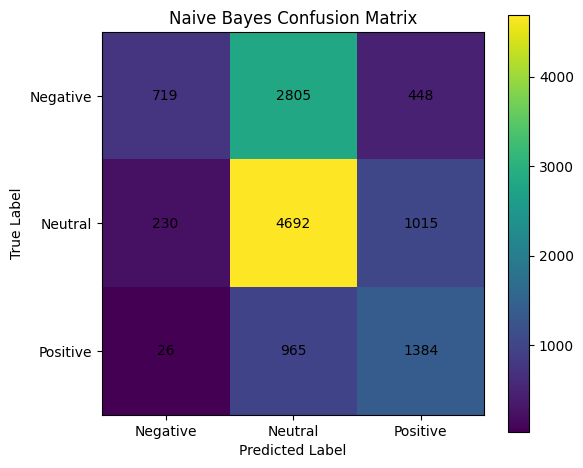

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1, 2],
    ["Negative", "Neutral", "Positive"]
)

plt.yticks(
    [0, 1, 2],
    ["Negative", "Neutral", "Positive"]
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [17]:
def predict_sentiment(tweet):

    processed = preprocess_tweet(tweet)

    features = vectorizer.transform([processed])

    prediction = model.predict(features)[0]

    probabilities = model.predict_proba(features)[0]

    sentiment = class_names[prediction]

    confidence = probabilities[prediction]

    return sentiment, confidence, probabilities

In [19]:
test_tweets = [
    "I absolutely love this!",
    "This is terrible.",
    "The movie was okay, nothing special.",
    "I don't really know how I feel about this.",
	"I do not really know how I feel about this.",
    "This is the best thing ever!"
]

for tweet in test_tweets:

    sentiment, confidence, probabilities = predict_sentiment(tweet)

    print(f"Tweet: {tweet}")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.2%}")
    print()

Tweet: I absolutely love this!
Sentiment: Positive
Confidence: 88.13%

Tweet: This is terrible.
Sentiment: Negative
Confidence: 54.49%

Tweet: The movie was okay, nothing special.
Sentiment: Positive
Confidence: 51.62%

Tweet: I don't really know how I feel about this.
Sentiment: Neutral
Confidence: 45.33%

Tweet: I do not really know how I feel about this.
Sentiment: Neutral
Confidence: 41.90%

Tweet: This is the best thing ever!
Sentiment: Positive
Confidence: 87.01%



In [27]:
for tweet in test_tweets:

	sentiment, confidence, probabilities = predict_sentiment(tweet)

	print("=" * 50)
	print(f"Tweet: {tweet}")
	print(f"Sentiment: {sentiment}")
	print(f"Confidence: {confidence:.2%}")

	print("\nClass probabilities:")

	for label, probability in zip(
		["Negative", "Neutral", "Positive"],
		probabilities
	):
		print(f"{label}: {probability:.2%}")
	print()

Tweet: I absolutely love this!
Sentiment: Positive
Confidence: 88.13%

Class probabilities:
Negative: 6.30%
Neutral: 5.57%
Positive: 88.13%

Tweet: This is terrible.
Sentiment: Negative
Confidence: 54.49%

Class probabilities:
Negative: 54.49%
Neutral: 23.29%
Positive: 22.22%

Tweet: The movie was okay, nothing special.
Sentiment: Positive
Confidence: 51.62%

Class probabilities:
Negative: 8.44%
Neutral: 39.94%
Positive: 51.62%

Tweet: I don't really know how I feel about this.
Sentiment: Neutral
Confidence: 45.33%

Class probabilities:
Negative: 26.24%
Neutral: 45.33%
Positive: 28.43%

Tweet: I do not really know how I feel about this.
Sentiment: Neutral
Confidence: 41.90%

Class probabilities:
Negative: 34.20%
Neutral: 41.90%
Positive: 23.90%

Tweet: This is the best thing ever!
Sentiment: Positive
Confidence: 87.01%

Class probabilities:
Negative: 6.77%
Neutral: 6.22%
Positive: 87.01%



In [29]:
while True:

    tweet = input("\nEnter a tweet (or type 'quit' to exit): ")

    if tweet.lower() == "quit":
        print("Goodbye!")
        break

    sentiment, confidence, probabilities = predict_sentiment(tweet)

    print(f"\nUser input: {tweet}")
    print("Prediction")
    print("-" * 30)

    print(f"Processed text: {preprocess_tweet(tweet)}")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.2%}")

    print("\nClass probabilities:")

    for label, probability in zip(
        ["Negative", "Neutral", "Positive"],
        probabilities
    ):
        print(f"{label}: {probability:.2%}")


User input: I do not really love this
Prediction
------------------------------
Processed text: i do not really love this
Sentiment: Positive
Confidence: 67.50%

Class probabilities:
Negative: 15.85%
Neutral: 16.65%
Positive: 67.50%
Goodbye!
